In [7]:
from langgraph.graph import StateGraph , START , END

In [8]:
from typing import TypedDict

class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    weight_cat:str

    

In [9]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]
    state["bmi"] = round(weight / (height**2) , 3)
    return state

def weight_cat(state:BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        state["weight_cat"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["weight_cat"] = "Normal"
    elif 25 <= bmi < 30:
        state["weight_cat"] = "Overweight"
    else:
        state["weight_cat"] = "Obese"

    return state



In [10]:
# defining the graph
graph = StateGraph(BMIState)

# Adding nodes to graph
graph.add_node("calculate_bmi" , calculate_bmi)
graph.add_node("weight_cat" , weight_cat)

"""
graph.add_node( node_name , function )
"""

# Adding edges to graph
graph.add_edge(START , "calculate_bmi")
graph.add_edge("calculate_bmi" , "weight_cat")
graph.add_edge("weight_cat" , END)



"""
graph.add_edge(starting_node , ending_node)

START -----> calculate_bmi -----> weight_cat -----> END

    START -----> calculate_bmi
    graph.add_edge(START , calculate_bmi)

    calculate_bmi -----> weight_cat
    graph.add_edge(calculate_bmi , weight_cat)

    weight_cat -----> END
    graph.add_edge(weight_cat , END)

NOTE : START , END -> Both are dummy Node, tells us from where node is starting and from where it get ended.
"""

# compile graph to check wheather our nodes are properly connected with edges
workflow = graph.compile()


In [11]:
# Execute Graph

initial_state = {
    "weight_kg" : 80,
    "height_m" : 1.73,
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'weight_cat': 'Overweight'}


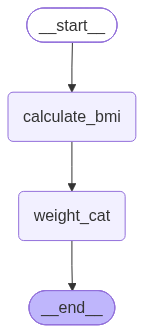

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())